# 데이터 로드

In [43]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = sns.load_dataset("titanic")
df.shape

(891, 15)

In [45]:
print(f"before : {df.shape}")


# row 기준 중복 데이터 삭제
df.drop_duplicates(keep='first', inplace=True, ignore_index=True)
print(f"after : {df.shape}")

before : (891, 15)
after : (784, 15)


# 완결성
- 결측값이 없어야한다.

In [46]:
(df.isnull().sum()/df.shape[0]).round(4).sort_values(ascending=False)

deck           0.7423
age            0.1352
embarked       0.0026
embark_town    0.0026
sex            0.0000
pclass         0.0000
survived       0.0000
fare           0.0000
parch          0.0000
sibsp          0.0000
class          0.0000
adult_male     0.0000
who            0.0000
alive          0.0000
alone          0.0000
dtype: float64

In [47]:
_tmp = df.isnull().sum() /df.shape[0]
(_tmp * 100).round(2).sort_values(ascending=False)

deck           74.23
age            13.52
embarked        0.26
embark_town     0.26
sex             0.00
pclass          0.00
survived        0.00
fare            0.00
parch           0.00
sibsp           0.00
class           0.00
adult_male      0.00
who             0.00
alive           0.00
alone           0.00
dtype: float64

<Axes: >

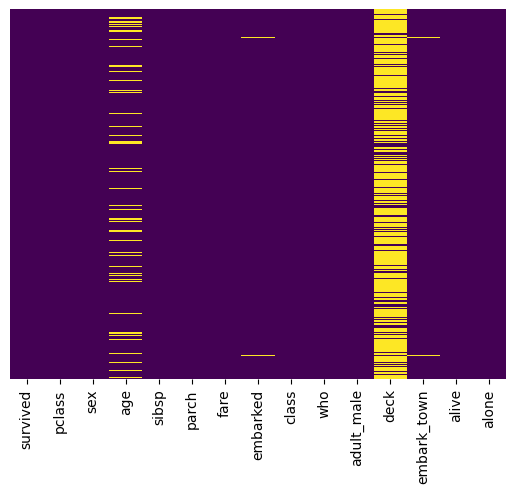

In [48]:
sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap = 'viridis'
)

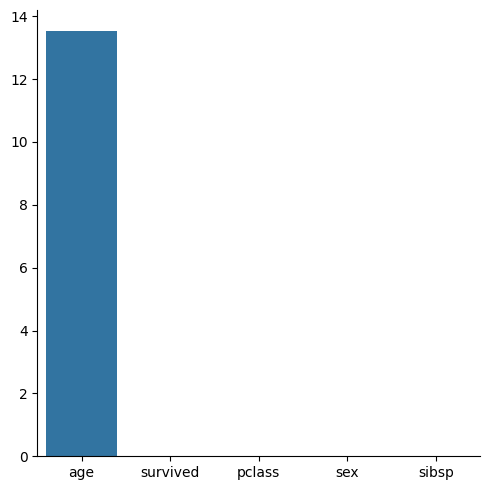

In [49]:
sns.catplot(
    (_tmp[:5] * 100).round(2).sort_values(ascending=False),
    kind = "bar"
)

In [50]:
#df.drop(columns=['deck'], inplace = True)
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [51]:
(df.isnull().sum()/len(df)).round(4).sort_values(ascending=False)[:5]

deck           0.7423
age            0.1352
embarked       0.0026
embark_town    0.0026
sex            0.0000
dtype: float64

In [52]:
# 범주형일때는 보통 최빈값으로 치환
# df['embarked'].mode() -> 결과값 벡터
# df['embarked'].mode().values[0] -> 결과값 스칼라
mode_embarked = df['embarked'].mode().values[0]

# 결측치를 최빈값으로 치환
df['embarked'] = df['embarked'].fillna(mode_embarked)

# 확인
# df['embarked'] -> 벡터
# df['embarked'].isnull() -> 벡터
# df['embarked'].isnull().sum() -> 스칼라(=결측치 수)
df['embarked'].isnull().sum()

np.int64(0)

In [53]:
# embark_town의 결측치 데이터 확인
cond = df["embark_town"].isnull() #결측치일 때 True

df[cond].head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
60,1,1,female,38.0,0,0,80.0,S,First,woman,False,B,NaN,yes,True
734,1,1,female,62.0,0,0,80.0,S,First,woman,False,B,NaN,yes,True


In [54]:
cond1 = df['pclass'] ==1
cond2 = df['sex'] == 'female'
cond = cond1&cond2

df[cond]['embark_town'].mode().values[0]

'Southampton'

In [55]:
mode_embarked = df[cond]['embarked'].mode().values[0]

# 결측치를 최빈값으로 치환
df['embarked'] = df['embarked'].fillna(mode_embarked)

# 확인
# df['embarked'] -> 벡터
# df['embarked'].isnull() -> 벡터
# df['embarked'].isnull().sum() -> 스칼라(=결측치 수)
df['embarked'].isnull().sum()

np.int64(0)